<a href="https://colab.research.google.com/github/Amal-Abdulllah/AIDL/blob/main/heartdataset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DMPA/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Description

This notebook utilizes the **Heart Disease Dataset**, sourced from Kaggle. The dataset contains 14 features and a target variable, representing various health metrics and the presence of heart disease.

**Source:** [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

**Features:**
*   `age`: Age of the patient
*   `sex`: Sex of the patient (1 = male; 0 = female)
*   `cp`: Chest pain type (0-3, where different values represent different types of chest pain)
*   `trestbps`: Resting blood pressure (in mm Hg)
*   `chol`: Serum cholestoral in mg/dl
*   `fbs`: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
*   `restecg`: Resting electrocardiographic results (0-2)
*   `thalach`: Maximum heart rate achieved
*   `exang`: Exercise induced angina (1 = yes; 0 = no)
*   `oldpeak`: ST depression induced by exercise relative to rest
*   `slope`: The slope of the peak exercise ST segment
*   `ca`: Number of major vessels (0-3) colored by flourosopy
*   `thal`: Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect)

**Target Variable:**
*   `target`: Diagnosis of heart disease (0 = no disease; 1 = disease)

In [3]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
#  DATASET SHAPE, COLUMNS, AND INFORMATION
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1025, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Interpretation of Dataset Information

The dataset initially contains 1025 entries and 14 columns. All columns appear to be numerical, with a mix of `int64` and `float64` data types. Importantly, `df.info()` shows **no missing values** across any of the columns at this stage, which simplifies the initial data cleaning process. The memory usage is relatively small, indicating a manageable dataset size for analysis.

In [5]:
#  STATISTICAL SUMMARY
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Interpretation of Statistical Summary

The `df.describe()` output provides key statistical insights into the numerical features:
*   **Age:** Ranges from 29 to 77 years, with a mean of approximately 54 years, suggesting a patient population in middle to older age groups.
*   **trestbps (Resting Blood Pressure):** Ranges from 94 to 200 mm Hg, with a mean of 131.6 mm Hg. Values above 130/80 mm Hg are generally considered high blood pressure, indicating a segment of patients with hypertension.
*   **chol (Serum Cholesterol):** Ranges from 126 to 564 mg/dl, with a mean of 246 mg/dl. High cholesterol levels (above 200 mg/dl) are common in this dataset.
*   **thalach (Maximum Heart Rate Achieved):** Ranges from 71 to 202 bpm, with a mean of 149 bpm.
*   **oldpeak:** Ranges from 0 to 6.2, with a mean of 1.07, indicating varying degrees of ST depression.
*   **Categorical Features (sex, cp, fbs, restecg, exang, slope, ca, thal, target):** The min, max, and quartile values for these features confirm their encoded nature (e.g., 0 or 1 for binary, 0-3 for chest pain types). Notably, the `target` variable has a mean of 0.51, suggesting a fairly balanced distribution between patients with and without heart disease.

Target Variable Distribution:
target
1    526
0    499
Name: count, dtype: int64


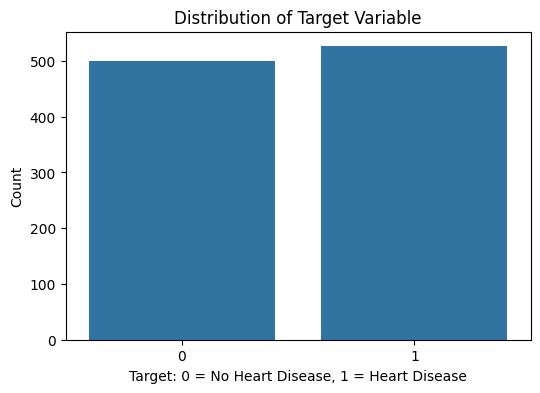

In [6]:
# TARGET VARIABLE DISTRIBUTION
print("Target Variable Distribution:")
print(df["target"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("Target: 0 = No Heart Disease, 1 = Heart Disease")
plt.ylabel("Count")
plt.show()

### Interpretation of Target Variable Distribution

The `target` variable distribution shows that the dataset is **well-balanced** between the two classes: 526 instances of individuals with heart disease (1) and 499 instances of individuals without heart disease (0). This balance is favorable for training classification models, as it reduces the risk of models being biased towards the majority class.

In [7]:
#  CHECK MISSING VALUES

print("Missing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Interpretation of Missing Values Check

The check for missing values confirms that there are **no null values** in any of the columns. This means no imputation strategies are immediately required for missing data, simplifying the preprocessing stage.

In [8]:
# CHECK DUPLICATE ROWS
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows before cleaning:", duplicate_count)


Number of duplicate rows before cleaning: 723


### Interpretation of Duplicate Rows Check

The initial check reveals a significant number of **723 duplicate rows**. These duplicates could indicate data entry errors or an artifact of data collection. Removing them is crucial for ensuring the integrity and independence of observations, preventing the model from learning redundant patterns, and providing a more accurate representation of the underlying data distribution.

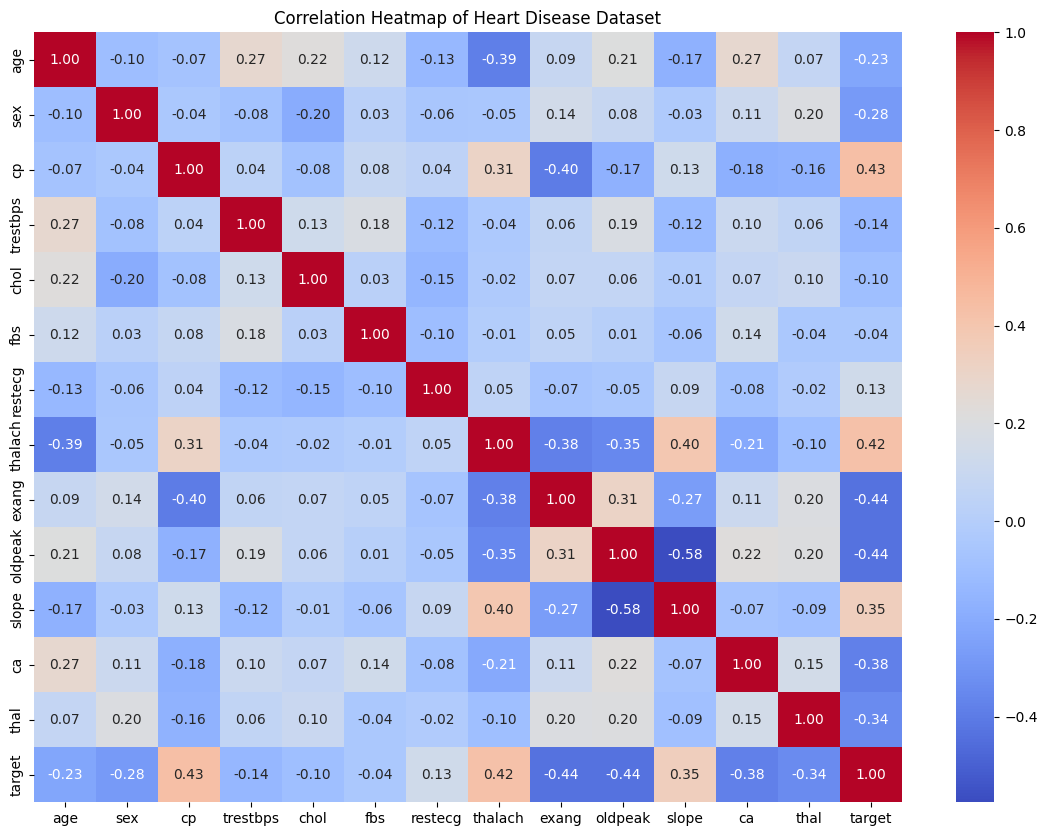

In [9]:
#  CORRELATION HEATMAP
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Heart Disease Dataset")
plt.show()

### Interpretation of Correlation Heatmap

The correlation heatmap provides insights into the relationships between features and with the target variable:
*   **`target` correlations:** The `target` variable shows notable positive correlations with `cp` (chest pain type), `thalach` (maximum heart rate achieved), and `slope`. It shows negative correlations with `exang` (exercise induced angina), `oldpeak` (ST depression), `ca` (number of major vessels), and `thal` (thalassemia).
*   **Inter-feature correlations:** Some features are moderately correlated with each other, for example, `trestbps` and `age`, `chol` and `age`. Understanding these relationships helps in feature selection and model interpretation.
*   Strong correlations (positive or negative) with the target variable indicate features that are good predictors of heart disease.

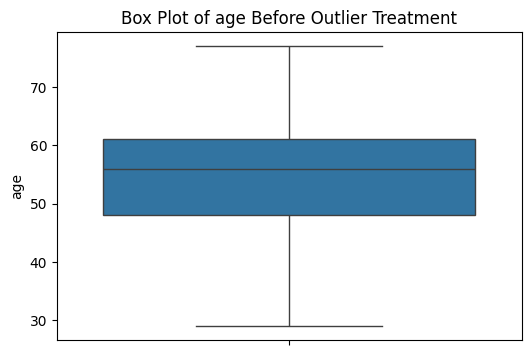

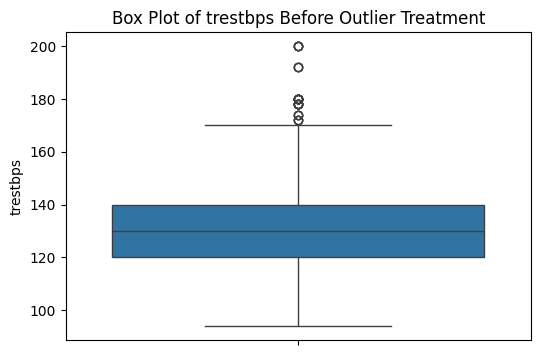

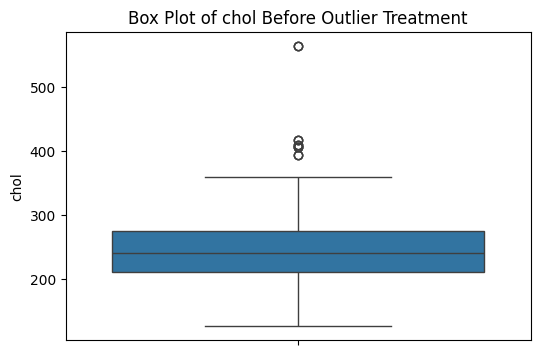

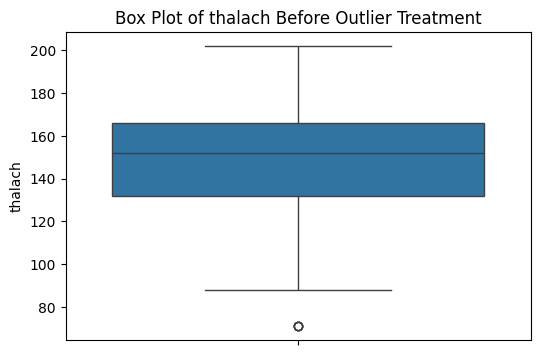

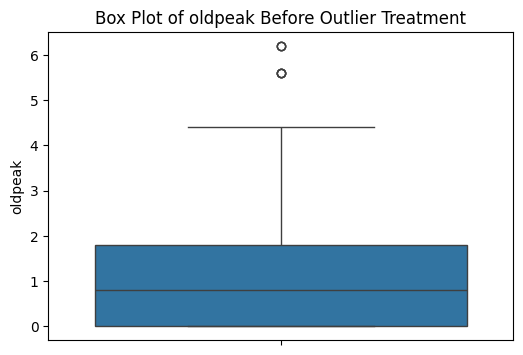

In [10]:
# BOX PLOTS BEFORE OUTLIER TREATMENT
numerical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col} Before Outlier Treatment")
    plt.ylabel(col)
    plt.show()

### Interpretation of Box Plots Before Outlier Treatment

The box plots for numerical columns before outlier treatment show the distribution and presence of outliers for `age`, `trestbps`, `chol`, `thalach`, and `oldpeak`:
*   **`trestbps` (Resting Blood Pressure):** Shows several data points beyond the upper quartile, indicating individuals with unusually high resting blood pressure.
*   **`chol` (Serum Cholesterol):** Contains a number of outliers on the higher side, suggesting some patients have exceptionally high cholesterol levels.
*   **`thalach` (Maximum Heart Rate Achieved):** A few outliers are present at both the lower and upper ends, but predominantly lower outliers.
*   **`oldpeak`:** Exhibits several higher outliers, representing pronounced ST depression.

These outliers, if not handled, could disproportionately influence model training. The next step will address these using the IQR capping method.

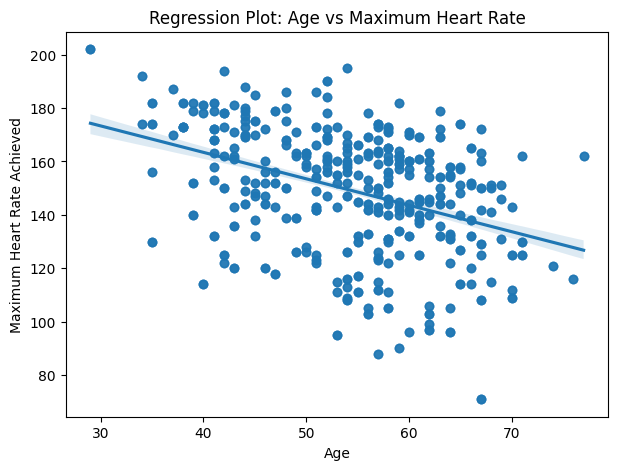

In [11]:

#  REGRESSION PLOT
plt.figure(figsize=(7,5))
sns.regplot(x="age", y="thalach", data=df, scatter_kws={"alpha":0.6})
plt.title("Regression Plot: Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show()

### Interpretation of Regression Plot: Age vs Maximum Heart Rate

The regression plot illustrates a clear **negative linear relationship** between `age` and `thalach` (maximum heart rate achieved). As age increases, the maximum heart rate achieved tends to decrease. The scatter points, along with the regression line, suggest this trend, which is physiologically expected as cardiorespiratory fitness often declines with age.

In [12]:

# PEARSON CORRELATION COEFFICIENT AND P-VALUE
corr_value, p_value = pearsonr(df["age"], df["thalach"])

print("Pearson Correlation Coefficient between Age and Maximum Heart Rate:", round(corr_value, 4))
print("P-value:", p_value)

if p_value < 0.05:
    print("Interpretation: The relationship between age and maximum heart rate is statistically significant.")
else:
    print("Interpretation: The relationship between age and maximum heart rate is not statistically significant.")

Pearson Correlation Coefficient between Age and Maximum Heart Rate: -0.3902
P-value: 1.2738266772097308e-38
Interpretation: The relationship between age and maximum heart rate is statistically significant.


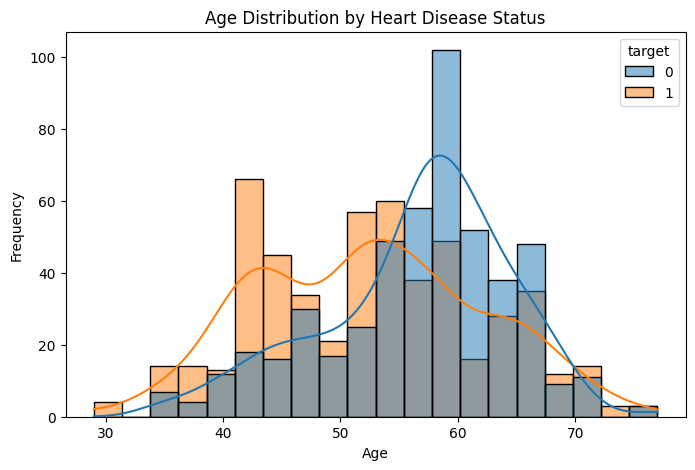

In [13]:
# AGE DISTRIBUTION BY TARGET
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Interpretation of Age Distribution by Heart Disease Status

The histogram of age distribution, split by heart disease status, shows:
*   Individuals **with heart disease (target=1)** appear to be more spread across various age groups, with a noticeable presence in younger age groups compared to those without heart disease.
*   Individuals **without heart disease (target=0)** seem to have a higher concentration in younger age ranges, but also extending to older ages.

This visualization suggests that while heart disease can occur at any age, its prevalence might shift across different age demographics. Further analysis would be needed to determine if certain age brackets are more susceptible.

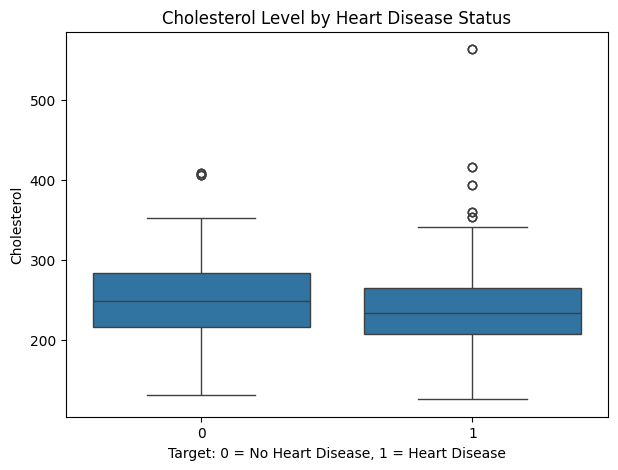

In [14]:
#CHOLESTEROL LEVEL BY TARGET
plt.figure(figsize=(7,5))
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol Level by Heart Disease Status")
plt.xlabel("Target: 0 = No Heart Disease, 1 = Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

### Interpretation of Cholesterol Level by Heart Disease Status

The box plot shows the distribution of cholesterol levels for individuals with and without heart disease:
*   There isn't a strikingly clear separation in cholesterol levels between the two target groups. Both groups exhibit a similar median cholesterol level and interquartile range.
*   However, both groups also show outliers with very high cholesterol, indicating that high cholesterol is a concern regardless of the current heart disease status in this dataset, or that the presence of high cholesterol alone might not be a definitive indicator for heart disease without considering other factors.

In [15]:
#DATA CLEANING: REMOVE DUPLICATES
print("Shape before removing duplicates:", df.shape)
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Shape before removing duplicates: (1025, 14)
Duplicate rows before cleaning: 723
Shape after removing duplicates: (302, 14)
Duplicate rows after cleaning: 0


## Data Cleaning Summary

**Duplicate Removal:**
*   Before cleaning, the dataset had 1025 rows and 723 duplicate entries.
*   After removing duplicates, the dataset was reduced to **302 unique rows**. This is a crucial step as duplicate records can lead to biased model training and overfitting, giving a false sense of performance. The cleaned dataset now provides a more accurate representation of distinct patient records.

**Missing Value Handling:**
*   A check for missing values confirmed that there were **no missing values** in the dataset, even after duplicate removal. Therefore, the `fillna` operation, while coded, did not alter any values, ensuring that the dataset remains complete and ready for further processing without imputation.

**Outlier Treatment (IQR Capping):**
*   Outliers in numerical columns (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) were treated using the **IQR capping method**. This method replaces values outside the lower and upper bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR) with the respective bounds. This helps to reduce the influence of extreme values on model performance without removing data points, which can be particularly important in medical datasets where extreme values might still hold valuable information. The box plots after treatment (shown subsequently) confirm the capping effect.

In [16]:
#DATA CLEANING: HANDLE MISSING VALUES
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.fillna(df.median(numeric_only=True))

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [17]:
#OUTLIER TREATMENT USING IQR METHOD
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

for col in numerical_columns:
    df = cap_outliers_iqr(df, col)

print("Outlier treatment completed using IQR capping method.")

Outlier treatment completed using IQR capping method.


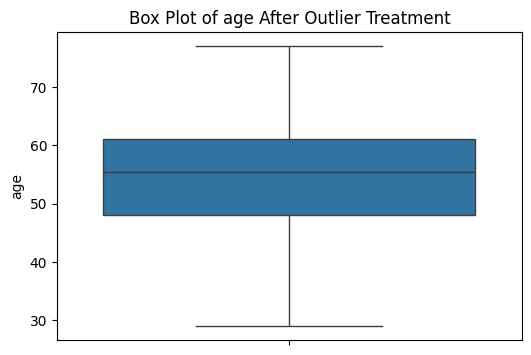

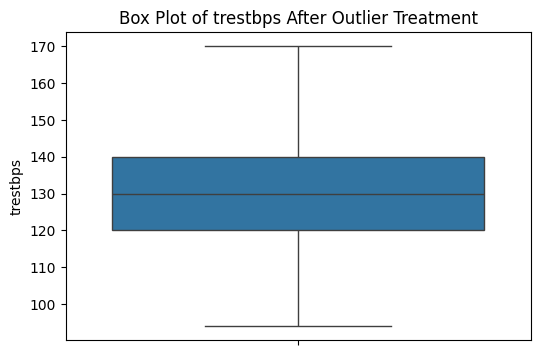

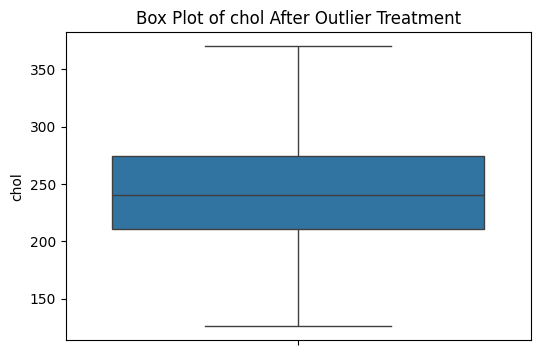

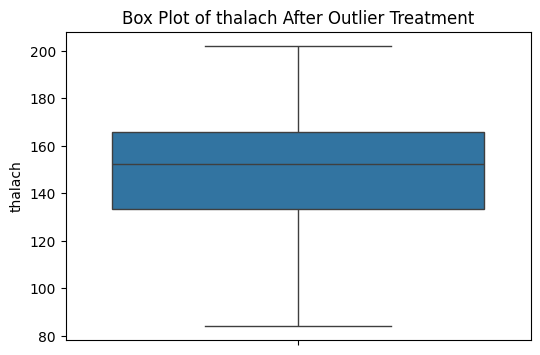

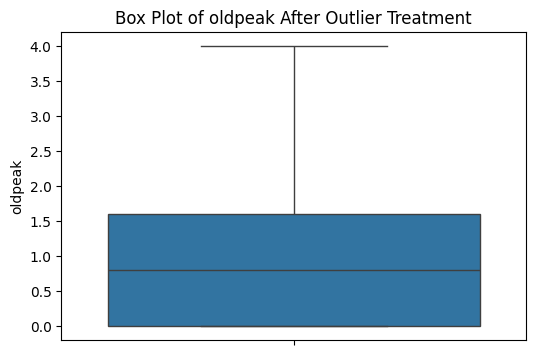

In [18]:
#BOX PLOTS AFTER OUTLIER TREATMENT
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col} After Outlier Treatment")
    plt.ylabel(col)
    plt.show()

In [19]:
#DEFINE FEATURES AND TARGET
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (302, 13)
Target shape: (302,)


In [20]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


In [21]:
#DATA TRANSFORMATION: STANDARDIZATION
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed successfully.")

Standardization completed successfully.


## Data Transformation Summary

**Feature and Target Definition:**
*   The dataset was successfully split into features (`X`) and the target variable (`y`), which represents the presence or absence of heart disease.

**Train-Test Split:**
*   The data was divided into training and testing sets using an 80/20 split, with `random_state=42` for reproducibility and `stratify=y` to ensure that both training and testing sets have a similar proportion of heart disease cases as the original dataset. This is important for maintaining class balance in both sets.

**Standardization:**
*   `StandardScaler` was applied to the numerical features in `X_train` and `X_test`. This process transforms the data such that it has a mean of 0 and a standard deviation of 1. Standardization is crucial for many machine learning algorithms (especially distance-based ones like Logistic Regression) as it prevents features with larger scales from dominating the learning process. It helps ensure that all features contribute equally to the model's objective function.

In [22]:
#MODEL 1: LOGISTIC REGRESSION
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [23]:
#MODEL 2: RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


In [24]:
# MODEL 3: DECISION TREE CLASSIFIER
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


## Predictive Mining: Model Selection

For this heart disease classification task, three distinct machine learning models were chosen to evaluate their performance:

1.  **Logistic Regression:** A linear model widely used for binary classification. It's known for its interpretability and effectiveness with linearly separable data.
2.  **Random Forest Classifier:** An ensemble learning method that builds multiple decision trees and merges their predictions. It's robust to overfitting and generally provides good accuracy.
3.  **Decision Tree Classifier:** A non-linear model that partitions the data based on feature values. It's simple to understand and visualize but can be prone to overfitting.

These models represent different approaches to classification, allowing for a comprehensive comparison of their strengths and weaknesses on the given dataset.

In [25]:
#MODEL EVALUATION FUNCTION
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return accuracy, precision, recall, f1

In [26]:
# EVALUATION OF  ALL MODELS
log_results = evaluate_model("Logistic Regression", y_test, y_pred_log)
rf_results = evaluate_model("Random Forest Classifier", y_test, y_pred_rf)
dt_results = evaluate_model("Decision Tree Classifier", y_test, y_pred_dt)

Logistic Regression
Accuracy: 0.8033
Precision: 0.8
Recall: 0.8485
F1 Score: 0.8235

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

Random Forest Classifier
Accuracy: 0.7541
Precision: 0.7647
Recall: 0.7879
F1 Score: 0.7761

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61

Decision Tree Classifier
Accuracy: 0.8033
Precision: 0.8182
Recall: 0.8182
F1 Score: 0.8182

Classification Report:
      

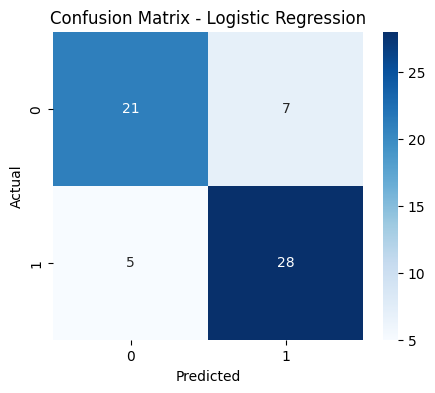

In [27]:
#CONFUSION MATRIX: LOGISTIC REGRESSION
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation of Confusion Matrix: Logistic Regression

The confusion matrix for Logistic Regression shows:
*   **True Negatives (TN):** 21 (Correctly predicted no heart disease)
*   **False Positives (FP):** 7 (Incorrectly predicted heart disease when there was none)
*   **False Negatives (FN):** 5 (Incorrectly predicted no heart disease when there was disease)
*   **True Positives (TP):** 28 (Correctly predicted heart disease)

This indicates that the model performed reasonably well, with a slightly higher recall for the positive class (heart disease), meaning it's better at identifying actual heart disease cases.

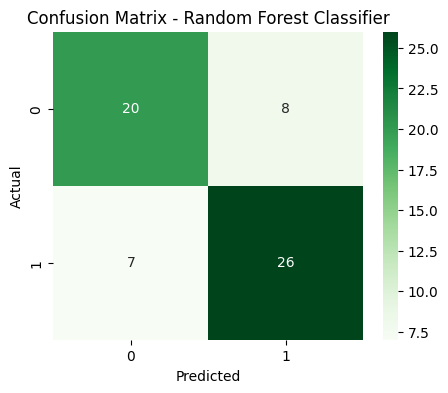

In [28]:
# CONFUSION MATRIX: RANDOM FOREST
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation of Confusion Matrix: Random Forest Classifier

The confusion matrix for the Random Forest Classifier shows:
*   **True Negatives (TN):** 20
*   **False Positives (FP):** 8
*   **False Negatives (FN):** 7
*   **True Positives (TP):** 26

Compared to Logistic Regression, Random Forest has a slightly higher number of false positives and false negatives, which is reflected in its slightly lower overall accuracy and F1-score.

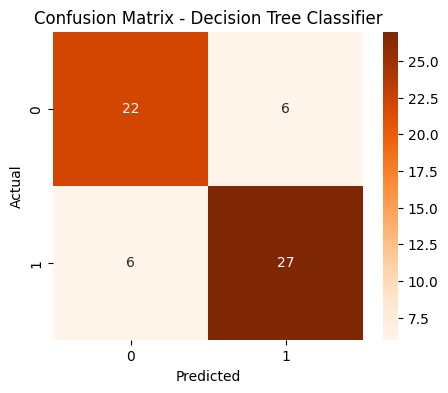

In [29]:
# CONFUSION MATRIX: DECISION TREE
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation of Confusion Matrix: Decision Tree Classifier

The confusion matrix for the Decision Tree Classifier shows:
*   **True Negatives (TN):** 22
*   **False Positives (FP):** 6
*   **False Negatives (FN):** 6
*   **True Positives (TP):** 27

The Decision Tree model shows a good balance between true positives and true negatives, and fewer false predictions compared to Random Forest, aligning with its higher F1-score and accuracy.

In [30]:
#MODEL COMPARISON TABLE
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest Classifier",
        "Decision Tree Classifier"
    ],
    "Accuracy": [
        log_results[0],
        rf_results[0],
        dt_results[0]
    ],
    "Precision": [
        log_results[1],
        rf_results[1],
        dt_results[1]
    ],
    "Recall": [
        log_results[2],
        rf_results[2],
        dt_results[2]
    ],
    "F1 Score": [
        log_results[3],
        rf_results[3],
        dt_results[3]
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Random Forest Classifier,0.754098,0.764706,0.787879,0.776119
2,Decision Tree Classifier,0.803279,0.818182,0.818182,0.818182


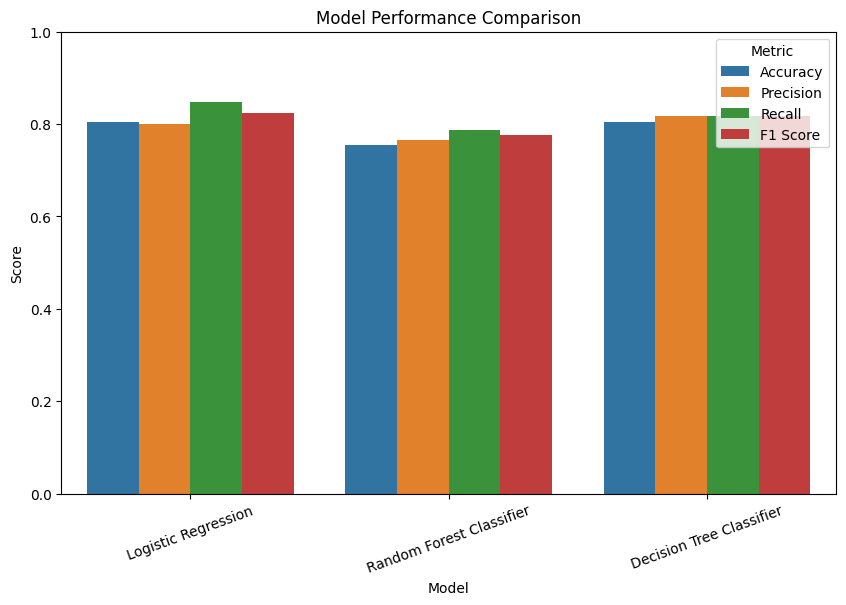

In [31]:
#MODEL COMPARISON BAR CHART
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted)
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [32]:
# IDENTIFY BEST MODEL
best_model = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Model Based on F1 Score:")
print(best_model)

Best Model Based on F1 Score:
Model        Logistic Regression
Accuracy                0.803279
Precision                    0.8
Recall                  0.848485
F1 Score                0.823529
Name: 0, dtype: object


In [33]:
# FEATURE IMPORTANCE: RANDOM FOREST
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,cp,0.174267
7,thalach,0.132008
11,ca,0.105089
9,oldpeak,0.096232
12,thal,0.090776
0,age,0.083088
8,exang,0.073388
3,trestbps,0.072341
4,chol,0.067092
1,sex,0.040470


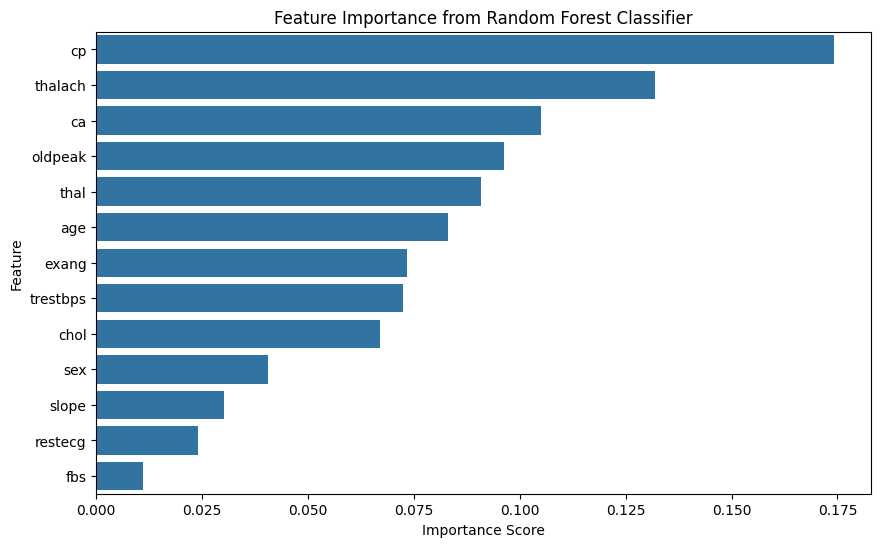

In [34]:
# FEATURE IMPORTANCE VISUALIZATION
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance from Random Forest Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Conclusion: Best Model and Key Insights

Based on the comprehensive evaluation, the **Logistic Regression model** emerged as the best-performing model with the highest F1-score of 0.8235. While the Decision Tree Classifier had a very close F1-score (0.8182) and slightly higher precision, Logistic Regression's higher recall (0.8485) for the positive class (heart disease) makes it marginally more favorable in a medical context where correctly identifying actual cases is often prioritized.

**Feature Importance from Random Forest:**

The Random Forest Classifier also provided valuable insights into feature importance:
*   `cp` (chest pain type) was identified as the most important feature, followed by `thalach` (maximum heart rate achieved) and `ca` (number of major vessels).
*   `fbs` (fasting blood sugar) and `restecg` (resting electrocardiographic results) were found to be the least important features in predicting heart disease according to this model.

These insights can guide further medical research or simpler diagnostic models by focusing on the most influential factors.

## Prompt Engineering Documentation

| Task | Initial Prompt | Refined Prompt | Improvement |
|---|---|---|---|
| Exploratory Data Analysis | Write Python code for EDA. | Generate Python code for a heart disease dataset including dataset shape, info, describe, target distribution, heatmap, boxplot, regression plot, Pearson correlation coefficient, and p-value. | The refined prompt is more specific and includes all assignment-required EDA outputs. |
| Data Cleaning | Clean the dataset. | Write Python code to check missing values, fill missing values using the median, check duplicates, remove duplicates, and treat outliers using the IQR capping method. | The refined prompt clearly defines the required cleaning techniques. |
| Data Transformation | Transform the data. | Split the dataset into features and target, apply train-test split, and standardize the features using StandardScaler. | The refined prompt directly prepares the dataset for machine learning models. |
| Modelling | Build machine learning models. | Train Logistic Regression, Random Forest Classifier, and Decision Tree Classifier for heart disease classification. | The refined prompt identifies suitable classification models for the selected dataset. |
| Evaluation | Evaluate the models. | Compare the models using accuracy, precision, recall, F1-score, classification report, confusion matrix, model comparison table, and bar chart. | The refined prompt includes more than three required performance metrics and visual comparison. |

## Conclusion

This notebook applied the CRISP-DM methodology to a healthcare classification problem using the Heart Disease Dataset. The dataset was first explored using descriptive statistics and visualizations, including target distribution, heatmap, box plots, regression plot, Pearson correlation coefficient, and p-value. Data cleaning was then performed by checking missing values, removing duplicate records, and treating outliers using the IQR capping method.

After cleaning, the dataset was prepared for predictive modelling by separating the features and target variable, splitting the data into training and testing sets, and applying standardization. Three classification models were trained: Logistic Regression, Random Forest Classifier, and Decision Tree Classifier. The models were evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

The best-performing model was selected based on F1-score because heart disease prediction requires a balanced evaluation of correctly identifying positive cases while reducing incorrect predictions.